In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json
import seaborn as sns

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv('../data/breast_cancer.csv')
X = df.drop('target', axis=1)
y = df['target']

In [24]:
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [5]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

In [6]:
logreg = LogisticRegression(max_iter=10000, C=100)
logreg.fit(x_train_scaled, y_train)
y_pred = logreg.predict(x_test_scaled)

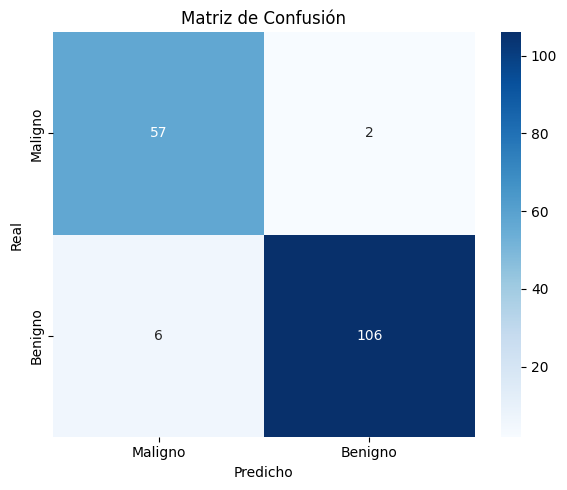

In [31]:
cm = confusion_matrix(y_test, y_pred)

# Etiquetas
labels = ["Maligno", "Benigno"]

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,    
    fmt="d",    
    cmap="Blues",       
    xticklabels=labels,
    yticklabels=labels,
    cbar=True       
)

plt.title("Matriz de Confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")

plt.tight_layout()
plt.show()

In [32]:
exactitud = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Exactitud:", exactitud * 100, "%")
print("Precision:", precision * 100, "%")
print("Recall:   ", recall * 100, "%")
print("F1-Score: ", f1 * 100, "%")

Exactitud: 95.32163742690058 %
Precision: 98.14814814814815 %
Recall:    94.64285714285714 %
F1-Score:  96.36363636363636 %


In [33]:
metrics = {
    "accuracy": float(exactitud),
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "confusion_matrix": cm.tolist()
}

with open("../models/lr_metrics.json", "w") as f:
    json.dump(metrics, f)


disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.savefig("../frontend/static/cm_logistic_regression.png")
plt.close()

print("Métricas guardadas")

Métricas guardadas


In [34]:
joblib.dump(logreg, '../models/logistic_regression.pkl')
joblib.dump(scaler,  '../models/scaler.pkl')

['../models/scaler.pkl']